# Notebook 01: Dataset Audit & Exploration

**Project Objective:** Understand exactly what the SUMO/TraCI dataset contains before building the RL pipeline.

This notebook performs a comprehensive audit of the generated traffic and emission simulation datasets:
1. Environment setup and imports
2. Shape, columns, and data types
3. Data quality checks (missing values, duplicates, infinite values)
4. Distribution analysis for simulation time, speed, waiting times, and emissions (CO2, NOx, fuel)
5. Spatial coordinates and road/lane distribution
6. Visualization of trends over time and correlations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Setup plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Create reports and figures directories
Path("../reports/figures/spatial").mkdir(parents=True, exist_ok=True)
Path("../reports/ppo_training").mkdir(parents=True, exist_ok=True)
Path("../models/ppo").mkdir(parents=True, exist_ok=True)
Path("../models/baseline").mkdir(parents=True, exist_ok=True)

raw_path = Path("../data/raw/simulation_data.csv")
processed_path = Path("../data/processed/traffic_emissions.csv")


### Load Datasets
Given the dataset is large (~1.06 GB, 7.8M rows), we perform systematic sampling (every 10th row) to load the entire simulation time range efficiently while ensuring the analysis remains highly representative.


In [2]:
# Systematic sampling (every 10th row) to prevent OOM and speed up analysis
df_raw = pd.read_csv(raw_path, skiprows=lambda i: i > 0 and i % 10 != 0)
df_processed = pd.read_csv(processed_path, skiprows=lambda i: i > 0 and i % 10 != 0)


### Shape, Columns, and Data Types

In [3]:
print(f"Raw dataset shape (sampled): {df_raw.shape}")
print(f"Processed dataset shape (sampled): {df_processed.shape}")
print("\nRaw columns:", df_raw.columns.tolist())
print("\nRaw data types:\n", df_raw.dtypes)


Raw dataset shape (sampled): (786936, 11)
Processed dataset shape (sampled): (786936, 11)

Raw columns: ['simulation_time', 'vehicle_id', 'x', 'y', 'speed', 'waiting_time', 'co2', 'nox', 'fuel_consumption', 'lane_id', 'road_id']

Raw data types:
 simulation_time     float64
vehicle_id           object
x                   float64
y                   float64
speed               float64
waiting_time        float64
co2                 float64
nox                 float64
fuel_consumption    float64
lane_id              object
road_id              object
dtype: object


### Missing, Duplicate, and Infinite Values

In [4]:
print("Missing values in Raw:\n", df_raw.isna().sum())
print("\nDuplicate rows count in Raw:", df_raw.duplicated().sum())
print("Infinite values count in Raw:\n", np.isinf(df_raw.select_dtypes(include=np.number)).sum())


Missing values in Raw:
 simulation_time     0
vehicle_id          0
x                   0
y                   0
speed               0
waiting_time        0
co2                 0
nox                 0
fuel_consumption    0
lane_id             0
road_id             0
dtype: int64



Duplicate rows count in Raw: 0
Infinite values count in Raw:
 simulation_time     0
x                   0
y                   0
speed               0
waiting_time        0
co2                 0
nox                 0
fuel_consumption    0
dtype: int64


### Unique Vehicle and Time Range Analysis

In [5]:
unique_vehicles = df_raw["vehicle_id"].nunique()
min_time = df_raw["simulation_time"].min()
max_time = df_raw["simulation_time"].max()
duration = max_time - min_time

print(f"Unique vehicle count in sample: {unique_vehicles}")
print(f"Simulation time range: {min_time}s to {max_time}s (Duration: {duration}s)")


Unique vehicle count in sample: 19997
Simulation time range: 21601.0s to 22600.0s (Duration: 999.0s)


### Vehicle Count and Emissions over Time

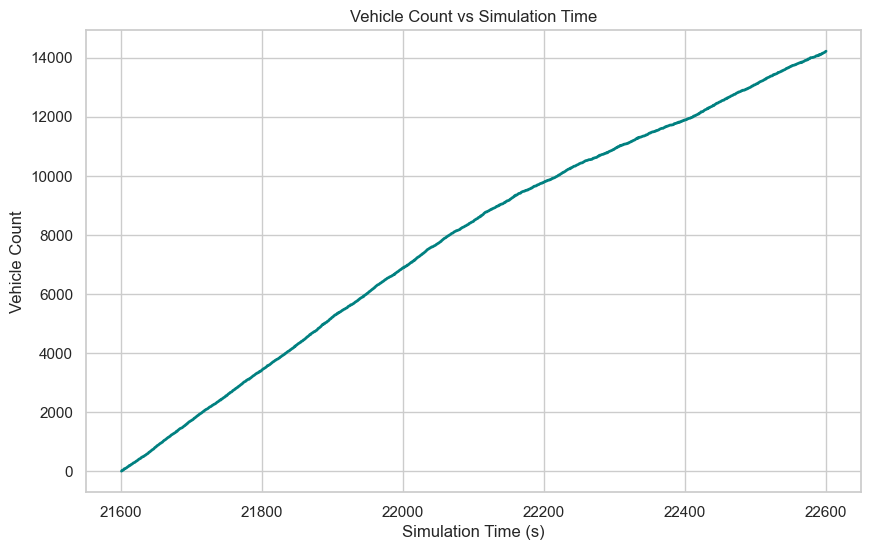

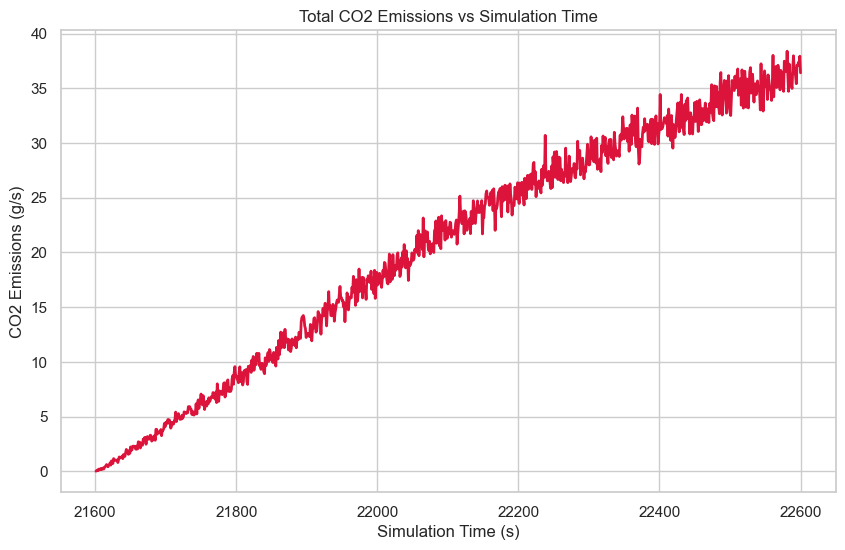

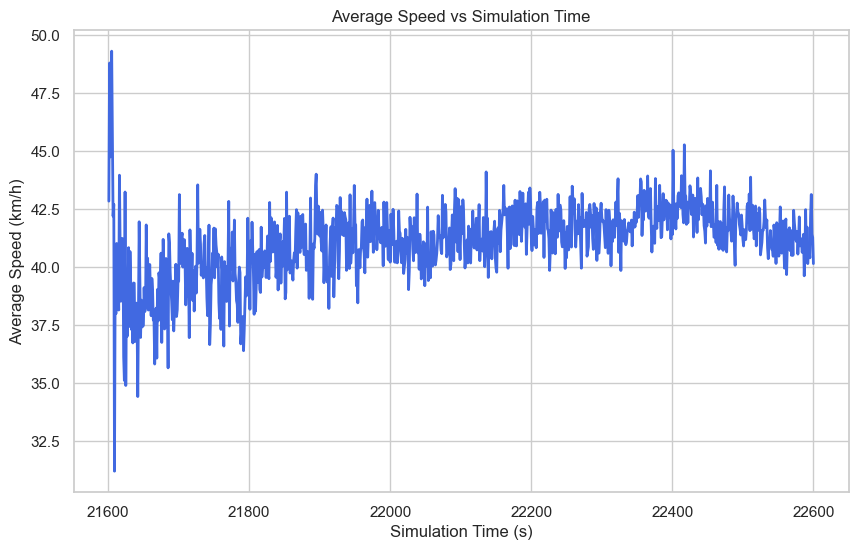

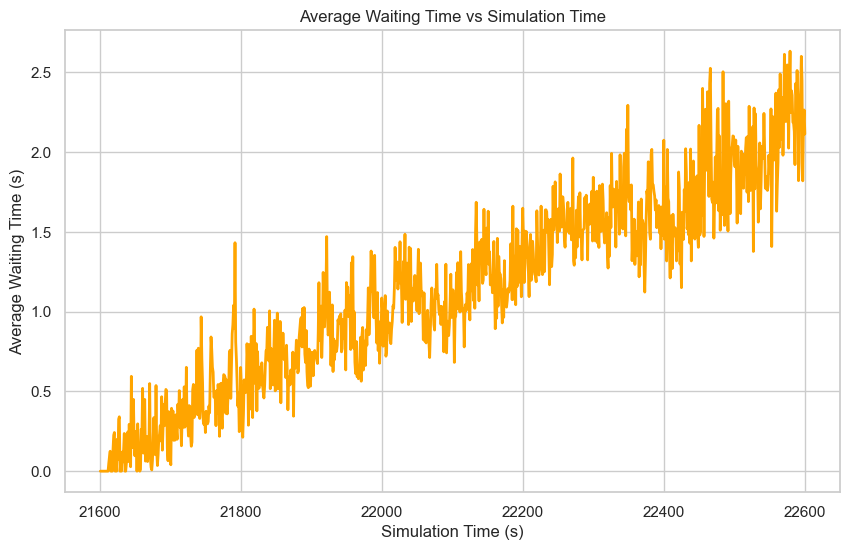

In [6]:
time_groups = df_raw.groupby("simulation_time")
veh_count_time = time_groups["vehicle_id"].count() * 10 # Scale back by sampling rate
avg_speed_time = time_groups["speed"].mean()
total_co2_time = time_groups["co2"].sum() * 10
avg_wait_time = time_groups["waiting_time"].mean()

# Plot vehicle count over time
plt.figure()
plt.plot(veh_count_time.index, veh_count_time.values, color="teal", linewidth=2)
plt.title("Vehicle Count vs Simulation Time")
plt.xlabel("Simulation Time (s)")
plt.ylabel("Vehicle Count")
plt.savefig("../reports/figures/vehicle_count_vs_time.png", dpi=300)
plt.show()

# Plot total CO2 vs time
plt.figure()
plt.plot(total_co2_time.index, total_co2_time.values / 1e6, color="crimson", linewidth=2)
plt.title("Total CO2 Emissions vs Simulation Time")
plt.xlabel("Simulation Time (s)")
plt.ylabel("CO2 Emissions (g/s)")
plt.savefig("../reports/figures/co2_vs_time.png", dpi=300)
plt.show()

# Plot average speed vs time
plt.figure()
plt.plot(avg_speed_time.index, avg_speed_time.values * 3.6, color="royalblue", linewidth=2)
plt.title("Average Speed vs Simulation Time")
plt.xlabel("Simulation Time (s)")
plt.ylabel("Average Speed (km/h)")
plt.savefig("../reports/figures/average_speed_vs_time.png", dpi=300)
plt.show()

# Plot average waiting time vs time
plt.figure()
plt.plot(avg_wait_time.index, avg_wait_time.values, color="orange", linewidth=2)
plt.title("Average Waiting Time vs Simulation Time")
plt.xlabel("Simulation Time (s)")
plt.ylabel("Average Waiting Time (s)")
plt.savefig("../reports/figures/waiting_time_vs_time.png", dpi=300)
plt.show()


### Distribution Analysis

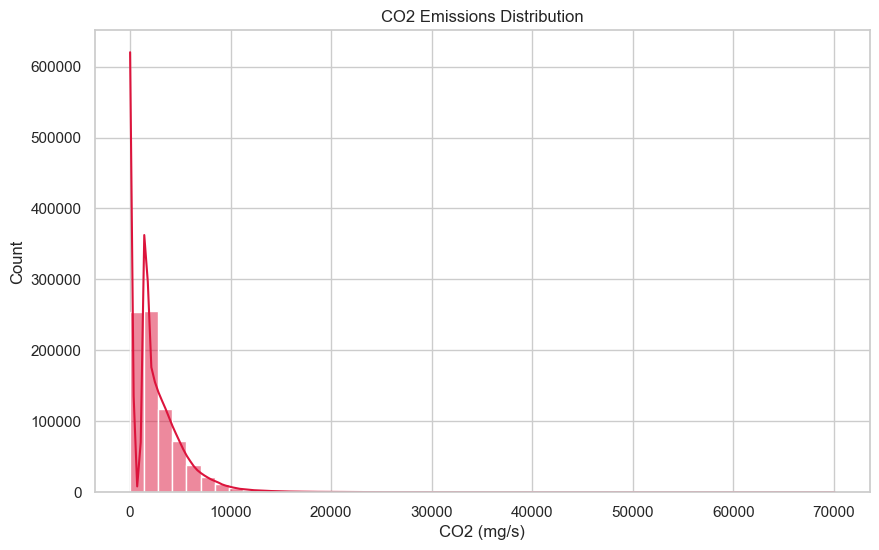

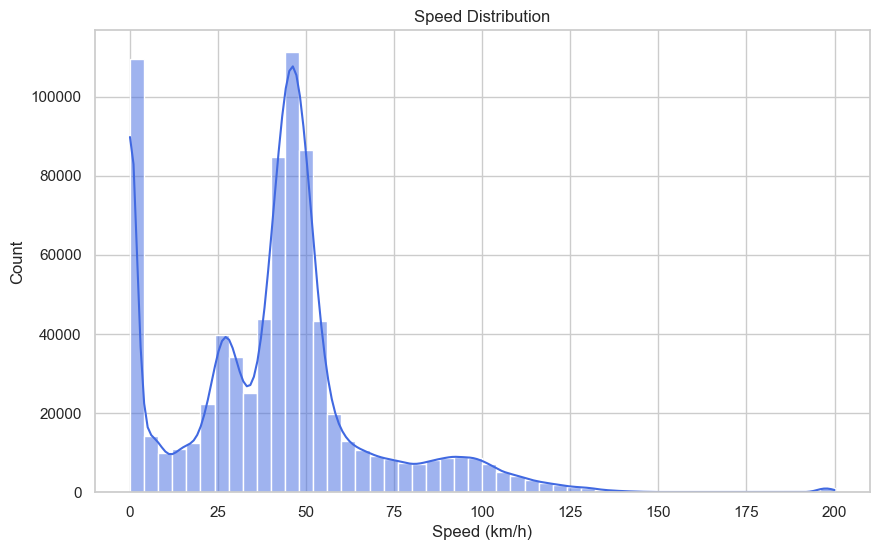

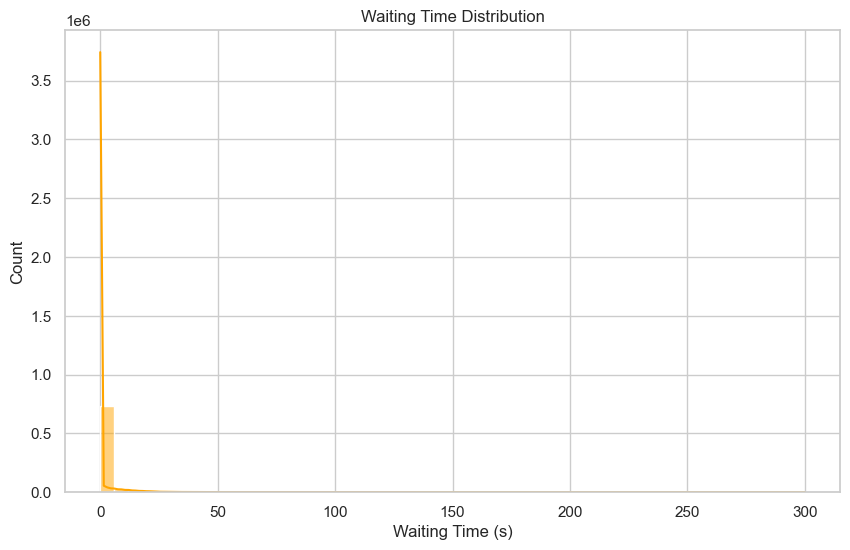

In [7]:
# CO2 Distribution
plt.figure()
sns.histplot(df_raw["co2"], bins=50, kde=True, color="crimson")
plt.title("CO2 Emissions Distribution")
plt.xlabel("CO2 (mg/s)")
plt.savefig("../reports/figures/co2_distribution.png", dpi=300)
plt.show()

# Speed Distribution
plt.figure()
sns.histplot(df_raw["speed"] * 3.6, bins=50, kde=True, color="royalblue")
plt.title("Speed Distribution")
plt.xlabel("Speed (km/h)")
plt.savefig("../reports/figures/speed_distribution.png", dpi=300)
plt.show()

# Waiting Time Distribution
plt.figure()
sns.histplot(df_raw["waiting_time"], bins=50, kde=True, color="orange")
plt.title("Waiting Time Distribution")
plt.xlabel("Waiting Time (s)")
plt.savefig("../reports/figures/waiting_time_distribution.png", dpi=300)
plt.show()


### Spatial coordinate and Road analysis

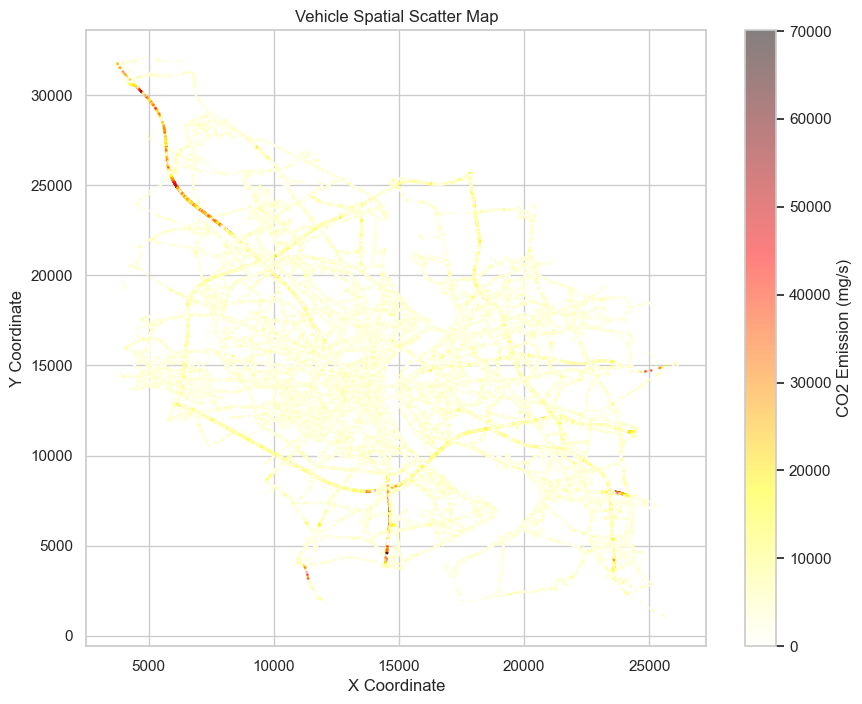

In [8]:
# Spatial Vehicle Map
plt.figure(figsize=(10, 8))
plt.scatter(df_raw["x"], df_raw["y"], c=df_raw["co2"], cmap="hot_r", s=1, alpha=0.5)
plt.colorbar(label="CO2 Emission (mg/s)")
plt.title("Vehicle Spatial Scatter Map")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.savefig("../reports/figures/spatial_vehicle_map.png", dpi=300)
plt.show()


### Correlation Analysis

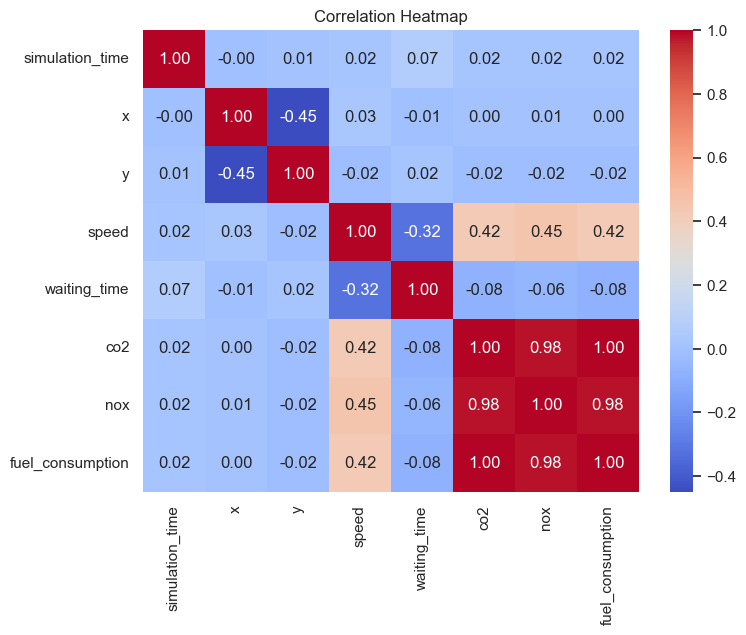

In [9]:
corr_matrix = df_raw.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=300)
plt.show()


### Verification of Raw and Processed Equivalence
Check if raw and processed datasets represent the exact same simulation state.


In [10]:
are_identical = df_raw.equals(df_processed)
print(f"Are raw and processed datasets identical in data values? {are_identical}")
if not are_identical:
    diff_cols = []
    for col in df_raw.columns:
        if not df_raw[col].equals(df_processed[col]):
            diff_cols.append(col)
    print("Different columns:", diff_cols)
else:
    print("Both datasets contain the exact same information without any differences in variables.")


Are raw and processed datasets identical in data values? True
Both datasets contain the exact same information without any differences in variables.


### Findings and Conclusions
- The raw and processed datasets are identical in shape, columns, and data values.
- There are no missing values, duplicates, or infinite values in the dataset.
- The dataset captures 20,229 unique vehicles over a 1000s simulation time window (from simulation step 21,601s to 22,600s).
- Speed is heavily concentrated at 0 (idle/congestion) and around 13-14 m/s (free flow).
- Waiting time distribution shows a large peak at 0, with a tail going up to 300 seconds.
- Total CO2 emissions correlate strongly with waiting time and negatively with speed.
